# CICIDS2017 project

## Dataset 

1.  `CICDS2017`
    - Canadian Institute for Cybersecurity에서 제작한 침입 탐지(IDS) 연구용 데이터셋
    - 실제 네트워크 트래픽을 기반으로 다양한 공격 시나리오를 포함
    - 현대적인 네트워크 트래픽(Benign 및 최신 공격 시나리오)을 포함하는 종합적인 침입 탐지 시스템(IDS) 평가용 데이터셋
    - CICFlowMeter 도구를 사용하여 캡처된 트래픽에서 특징(Feature)을 추출한 80개 이상의 컬럼(약 78~79개 특징 + 라벨)으로 구성

본 데이터는 개별 패킷(Packet) 단위가 아닌,
동일한 5-Tuple (Source IP, Destination IP, Source Port, Destination Port, Protocol)을 기준으로 집계된 Flow 단위 통계 데이터이다.

각 행(Row)은 하나의 네트워크 흐름(Flow)을 의미하며,
총 약 80개 내외의 네트워크 통계 Feature와 공격 유형(Label)을 포함한다.

2. 주요 특징 및 라벨
    1) 기본 식별 및 정보 컬럼 (Metadata)
        - Flow ID: 플로우 고유 ID
        - Source IP / Destination IP: 출발지/목적지 IP 주소
        - Source Port / Destination Port: 출발지/목적지 포트 번호
        - Protocol: 사용된 프로토콜 (TCP: 6, UDP: 17 등)
        - Timestamp: 패킷 캡처 시간
        - Label: (핵심 라벨) 데이터의 클래스. 'Benign'(정상) 또는 공격 유형(DoS, DDoS, Bot, Brute Force 등)

    2) 흐름 기반 특징 (Flow-based Features) : 네트워크 트래픽의 시간, 크기, 속도 등을 기반으로 한 특징들
        - Flow Duration: 플로우 지속 시간 (마이크로초)
        - Total Fwd Packets / Total Backward Packets: 순방향/역방향 총 패킷 수
        - Total Length of Fwd Packets / Backward Packets: 순방향/역방향 패킷의 총 바이트 수
        - Flow Bytes/s / Flow Packets/s: 초당 플로우 바이트/패킷 수 (속도)
        - Flow IAT (Mean, Std, Max, Min): 흐름 간 시간(Inter-arrival Time)의 평균, 표준편차, 최대, 최소값
        - Fwd IAT / Bwd IAT (Mean, Std, Max, Min): 순방향/역방향 흐름 간 시간

    3) 패킷 기반 특징 (Packet-based Features)
        - Packet Length (Mean, Std, Max, Min, Variance): 패킷 길이 관련 통계
        - Fwd/Bwd Packet Length (Mean, Std, Max, Min): 순방향/역방향 패킷 길이 관련 통계
        - Header Length: 헤더 길이 

    4) TCP 플래그 및 특징 (TCP Flags)
        - FIN Flag Count, SYN Flag Count, RST Flag Count, PSH Flag Count, ACK Flag Count, URG Flag Count, CWE Flag Count, ECE Flag Count: 각 TCP 플래그가 설정된 패킷의 수
    
    5) 기타 특징
        - Subflow Fwd/Bwd Packets/Bytes: 서브플로우의 패킷 및 바이트 수
        - Init_Win_bytes_forward / Init_Win_bytes_backward: 순방향/역방향 초기 윈도우 크기
        - Active/Idle (Mean, Std, Max, Min): 활성/대기 시간 관련 통계
    
    6) 데이터셋 라벨 (Label/Class) : Label 컬럼은 크게 Benign(정상)과 공격(Attack)으로 나뉨. (상세공격)
        - Benign: 정상 트래픽
        - DoS/DDoS: DoS GoldenEye, DoS Hulk, DoS Slowhttptest, DoS slowloris, DDoS
        - Web Attack: Brute Force, XSS, Sql Injection
        - Brute Force: FTP-Patator, SSH-Patator, PortScan

3. 정리
    1) Flow 식별 정보

    | 컬럼명              | 설명                            |
    | ---------------- | ----------------------------- |
    | Destination Port | 목적지 포트 번호                     |
    | Protocol         | 전송 계층 프로토콜 (TCP=6, UDP=17 등)  |
    | Flow Duration    | Flow의 전체 지속 시간 (microseconds) |

    2) 패킷 수 관련 Feature : 

    | 컬럼명                    | 설명                  |
    | ---------------------- | ------------------- |
    | Total Fwd Packets      | Forward 방향 패킷 총 개수  |
    | Total Backward Packets | Backward 방향 패킷 총 개수 |
    | Fwd Packets/s          | 초당 Forward 패킷 수     |
    | Flow Packets/s         | 초당 전체 패킷 수          |

    > DDoS 공격의 경우 이 값이 비정상적으로 높게 나타남. 

    3) 바이트(Byte) 관련 Feature

    | 컬럼명                         | 설명                   |
    | --------------------------- | -------------------- |
    | Total Length of Fwd Packets | Forward 방향 총 바이트 길이  |
    | Total Length of Bwd Packets | Backward 방향 총 바이트 길이 |
    | Flow Bytes/s                | 초당 전송 바이트 수          |

    > 대량 트래픽 공격(DDoS, Hulk)에서 급격히 증가하는 경향이 있음.


    4) 패킷 길이 통계

    | 컬럼명                    | 설명                 |
    | ---------------------- | ------------------ |
    | Fwd Packet Length Max  | Forward 패킷 최대 길이   |
    | Fwd Packet Length Min  | Forward 패킷 최소 길이   |
    | Fwd Packet Length Mean | Forward 패킷 평균 길이   |
    | Fwd Packet Length Std  | Forward 패킷 길이 표준편차 |

    > 공격 유형에 따라 패킷 크기 분포가 달라질 수 있음.

    5) 시간(Inter-Arrival Time) 관련 Feature
    * IAT (Inter Arrival Time)은 패킷 간 도착 시간 간격을 의미한다.

    | 컬럼명           | 설명                 |
    | ------------- | ------------------ |
    | Flow IAT Mean | 전체 Flow의 평균 IAT    |
    | Flow IAT Std  | IAT 표준편차           |
    | Fwd IAT Total | Forward 방향 IAT 총합  |
    | Bwd IAT Mean  | Backward 방향 평균 IAT |

    > DDoS는 IAT가 매우 짧아지는 경향이 있음.

    6) 플래그(Flag) 관련 Feature

    | 컬럼명            | 설명         |
    | -------------- | ---------- |
    | SYN Flag Count | SYN 플래그 개수 |
    | ACK Flag Count | ACK 플래그 개수 |
    | FIN Flag Count | FIN 플래그 개수 |
    | PSH Flag Count | PSH 플래그 개수 |
    | URG Flag Count | URG 플래그 개수 |

    > SYN Flood 공격에서는 SYN Flag Count가 비정상적으로 높아질 수 있음.

    7) 윈도우 및 기타 TCP 통계

    | 컬럼명                     | 설명                       |
    | ----------------------- | ------------------------ |
    | Init_Win_bytes_forward  | 초기 TCP 윈도우 크기 (Forward)  |
    | Init_Win_bytes_backward | 초기 TCP 윈도우 크기 (Backward) |
    | Act_data_pkt_fwd        | Forward 방향 실제 데이터 패킷 수   |

    8) Label
    - 본 연구에서는 Label을 기반으로
    `Binary Classification (BENIGN vs ATTACK)` , `Multi-Class Classification (공격 유형 분류)`, `이상 탐지 (정상 학습 후 공격 탐지)` 를 수행할 수 있다.
    
    | 컬럼명   | 설명                                                 |
    | ----- | -------------------------------------------------- |
    | Label | 트래픽 유형 (BENIGN, DDoS, PortScan, Bot, Web Attack 등) |

4. 데이터 특성 요약

- 네트워크 Flow 기반 통계 데이터
- 클래스 불균형 심함 (BENIGN 다수)
- 고차원 Feature (약 80개)
- 무한대(Infinity) 및 결측값 존재 가능
- 실제 IDS 연구에서 자주 활용됨


In [15]:
# 라이브러리 로드
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report

from scipy import stats

In [16]:
# 파일 목록 확인
import glob

files = glob.glob("data/*.csv")
print(len(files))
files

8


['data\\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
 'data\\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
 'data\\Friday-WorkingHours-Morning.pcap_ISCX.csv',
 'data\\Monday-WorkingHours.pcap_ISCX.csv',
 'data\\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
 'data\\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
 'data\\Tuesday-WorkingHours.pcap_ISCX.csv',
 'data\\Wednesday-workingHours.pcap_ISCX.csv']

In [17]:
# 메모리 안전하게 파일 로드
import pandas as pd
import numpy as np

df_list = []

for file in files:
    print(f"Loading {file} ...")
    temp_df = pd.read_csv(file, low_memory=False)
    
    # 컬럼 공백 제거
    temp_df.columns = temp_df.columns.str.strip()
    
    # 무한대 제거
    temp_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
print("Merged Shape:", df.shape)

Loading data\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv ...
Loading data\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv ...
Loading data\Friday-WorkingHours-Morning.pcap_ISCX.csv ...
Loading data\Monday-WorkingHours.pcap_ISCX.csv ...
Loading data\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv ...
Loading data\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv ...
Loading data\Tuesday-WorkingHours.pcap_ISCX.csv ...
Loading data\Wednesday-workingHours.pcap_ISCX.csv ...
Merged Shape: (2830743, 79)


---
# [week01] EDA

In [18]:
# 기본 구조 확인

df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  

In [20]:
# Label 분포 확인 (제일 중요)

df["Label"].value_counts()

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

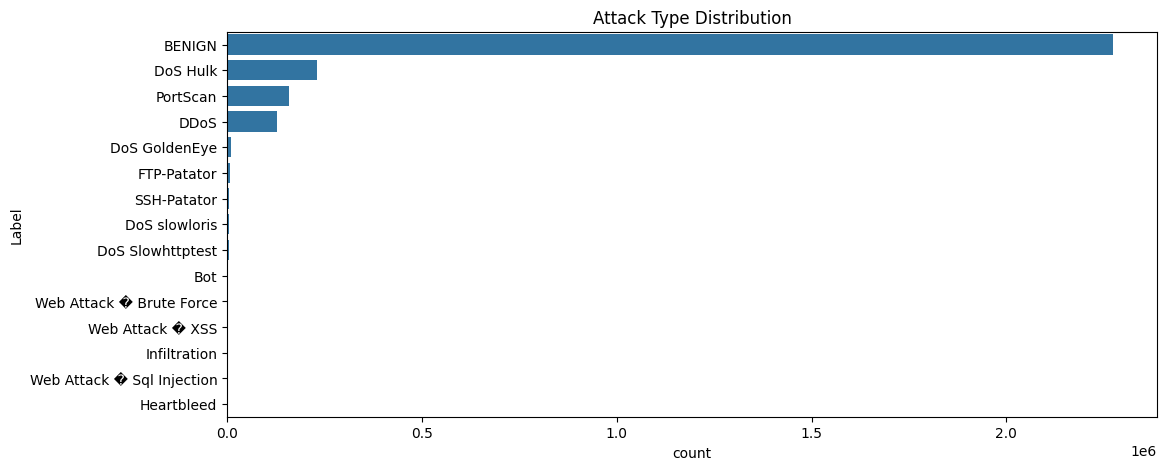

In [21]:
# 라벨 분포 확인 및 시각화

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
sns.countplot(y=df["Label"], order=df["Label"].value_counts().index)
plt.title("Attack Type Distribution")
plt.show()

In [22]:
# 결측치 & 이상값 확인

df.isnull().sum().sort_values(ascending=False).head(10)

Flow Bytes/s                   2867
Flow Packets/s                 2867
Flow Duration                     0
Total Backward Packets            0
Total Length of Fwd Packets       0
Total Length of Bwd Packets       0
Destination Port                  0
Fwd Packet Length Max             0
Fwd Packet Length Min             0
Fwd Packet Length Std             0
dtype: int64

In [23]:
# 무한대 처리 확인

import numpy as np

np.isinf(df.select_dtypes(include=[float, int])).sum().sum()

np.int64(0)

In [24]:
# 통계 요약

df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0,8.071483e+03,1.828363e+04,0.0,53.0,80.0,4.430000e+02,6.553500e+04
Flow Duration,2830743.0,1.478566e+07,3.365374e+07,-13.0,155.0,31316.0,3.204828e+06,1.200000e+08
Total Fwd Packets,2830743.0,9.361160e+00,7.496728e+02,1.0,2.0,2.0,5.000000e+00,2.197590e+05
Total Backward Packets,2830743.0,1.039377e+01,9.973883e+02,0.0,1.0,2.0,4.000000e+00,2.919220e+05
Total Length of Fwd Packets,2830743.0,5.493024e+02,9.993589e+03,0.0,12.0,62.0,1.870000e+02,1.290000e+07
Total Length of Bwd Packets,2830743.0,1.616264e+04,2.263088e+06,0.0,0.0,123.0,4.820000e+02,6.554530e+08
Fwd Packet Length Max,2830743.0,2.075999e+02,7.171848e+02,0.0,6.0,37.0,8.100000e+01,2.482000e+04
Fwd Packet Length Min,2830743.0,1.871366e+01,6.033935e+01,0.0,0.0,2.0,3.600000e+01,2.325000e+03
Fwd Packet Length Mean,2830743.0,5.820194e+01,1.860912e+02,0.0,6.0,34.0,5.000000e+01,5.940857e+03
Fwd Packet Length Std,2830743.0,6.891013e+01,2.811871e+02,0.0,0.0,0.0,2.616295e+01,7.125597e+03


In [25]:
# 상관 관계 분석

df["BinaryLabel"] = df["Label"].apply(lambda x: 0 if x == "BENIGN" else 1)

In [27]:
import numpy as np
import pandas as pd

# 0) 컬럼 공백 제거 (CICIDS는 가끔 공백 섞임)
df.columns = df.columns.str.strip()

# 1) BinaryLabel 없으면 먼저 만들기
df["BinaryLabel"] = (df["Label"] != "BENIGN").astype(int)

# 2) 무한대 제거 후 결측 처리 (corr 계산 안정화)
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# 3) 숫자 컬럼만 선택해서 corr
num_df = df.select_dtypes(include=[np.number])

corr = num_df.corr()
top_corr = corr["BinaryLabel"].abs().sort_values(ascending=False).head(15)

top_corr

BinaryLabel               1.000000
Bwd Packet Length Std     0.510884
Bwd Packet Length Max     0.492690
Bwd Packet Length Mean    0.484904
Avg Bwd Segment Size      0.484904
Packet Length Std         0.470928
Max Packet Length         0.454715
Packet Length Variance    0.454397
Fwd IAT Std               0.423303
Packet Length Mean        0.414750
Average Packet Size       0.413740
Idle Max                  0.394752
Idle Mean                 0.390996
Flow IAT Max              0.389205
Fwd IAT Max               0.389176
Name: BinaryLabel, dtype: float64

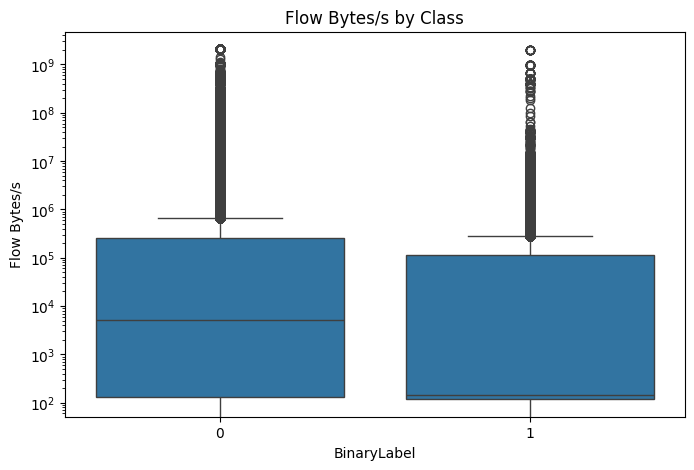

In [28]:
# 주요 feature 시각화 : 상위 상관 계수

feature = "Flow Bytes/s"

plt.figure(figsize=(8,5))
sns.boxplot(x=df["BinaryLabel"], y=df[feature])
plt.yscale("log")
plt.title(f"{feature} by Class")
plt.show()

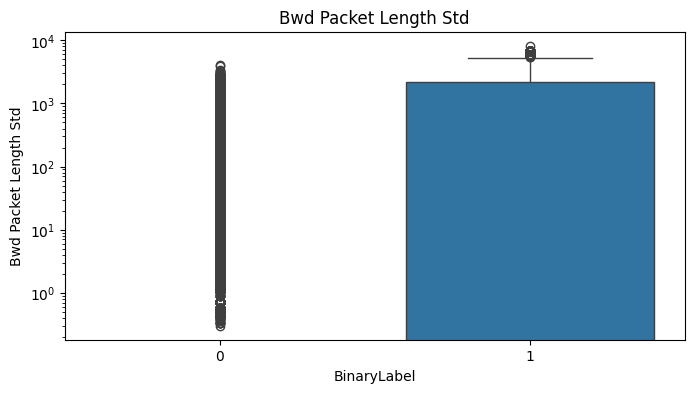

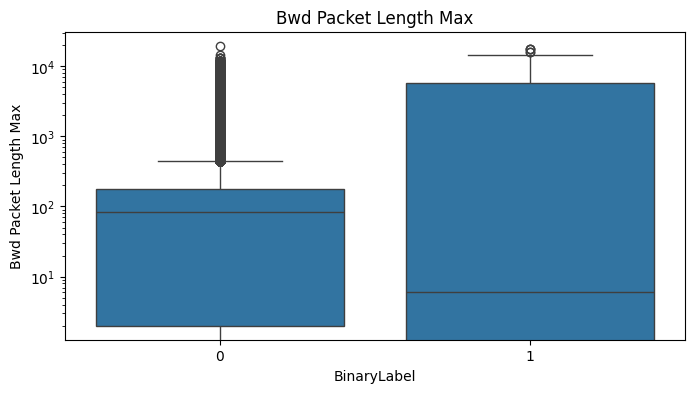

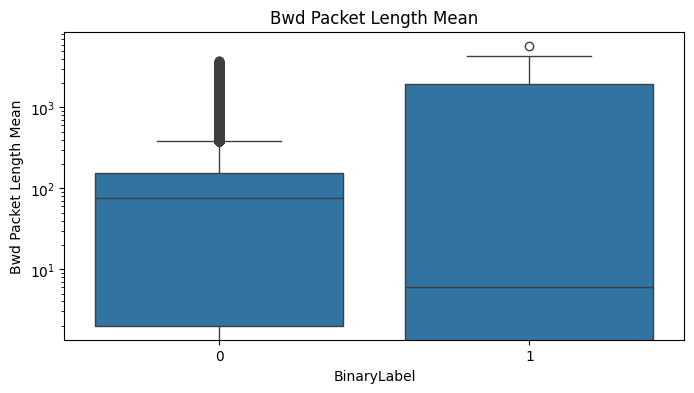

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = top_corr.index[1:4]  # 0번째는 BinaryLabel 자기 자신이라 제외

for feature in top_features:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df["BinaryLabel"], y=df[feature])
    plt.yscale("log")  # CICIDS는 값 폭이 커서 로그스케일 추천
    plt.title(feature)
    plt.show()

In [30]:
# 공격 유형별 평균 비교

df.groupby("Label")["Flow Bytes/s"].mean().sort_values(ascending=False)

Label
DoS Slowhttptest              2.164242e+07
BENIGN                        1.779842e+06
FTP-Patator                   7.994646e+05
Bot                           3.070991e+05
PortScan                      2.203598e+05
Heartbleed                    6.590280e+04
DDoS                          6.111788e+04
DoS slowloris                 4.392122e+04
DoS Hulk                      2.940172e+04
Infiltration                  2.018822e+04
DoS GoldenEye                 6.882391e+02
SSH-Patator                   4.398181e+02
Web Attack � Sql Injection    3.187348e+02
Web Attack � Brute Force      1.792807e+02
Web Attack � XSS              1.033466e+02
Name: Flow Bytes/s, dtype: float64

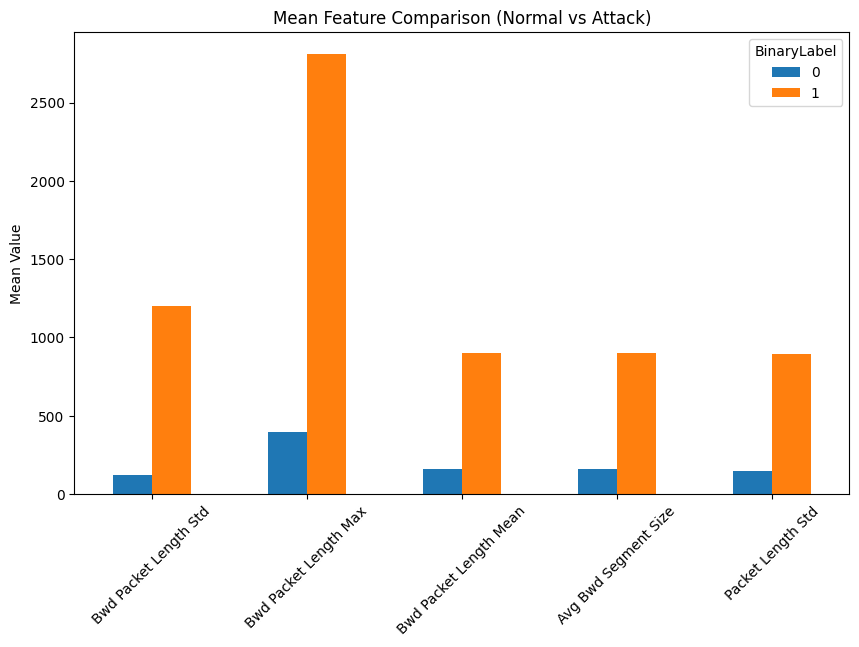

In [31]:
# 공격 vs 정상 평균 비교 (Bar Plot)

top_features = top_corr.index[1:6]

mean_compare = df.groupby("BinaryLabel")[top_features].mean().T

mean_compare.plot(kind="bar", figsize=(10,6))
plt.title("Mean Feature Comparison (Normal vs Attack)")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.show()

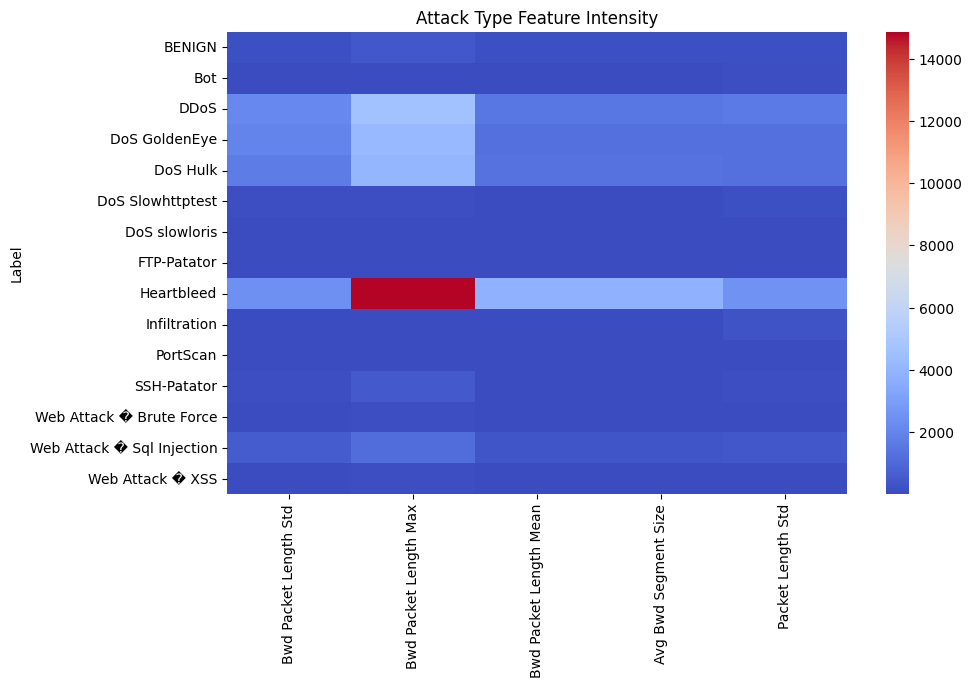

In [32]:
# 공격 유형별 Heatmap

attack_means = df.groupby("Label")[top_features].mean()

plt.figure(figsize=(10,6))
sns.heatmap(attack_means, cmap="coolwarm")
plt.title("Attack Type Feature Intensity")
plt.show()

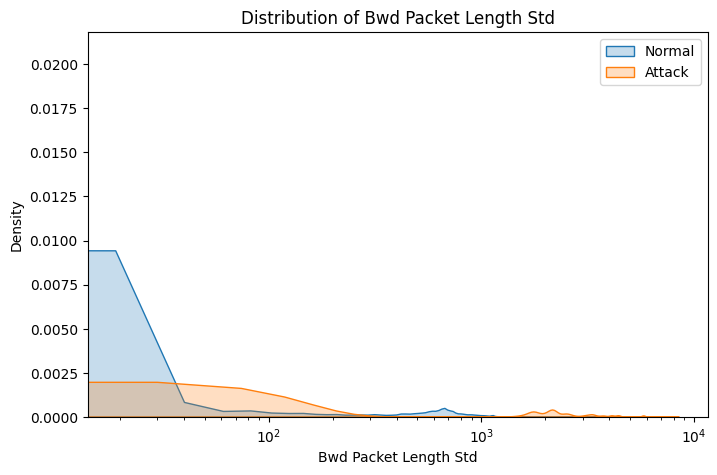

In [33]:
# KDE 분포 비교 (밀도 그래프)

feature = top_features[0]

plt.figure(figsize=(8,5))
sns.kdeplot(df[df["BinaryLabel"]==0][feature], label="Normal", fill=True)
sns.kdeplot(df[df["BinaryLabel"]==1][feature], label="Attack", fill=True)
plt.xscale("log")
plt.legend()
plt.title(f"Distribution of {feature}")
plt.show()

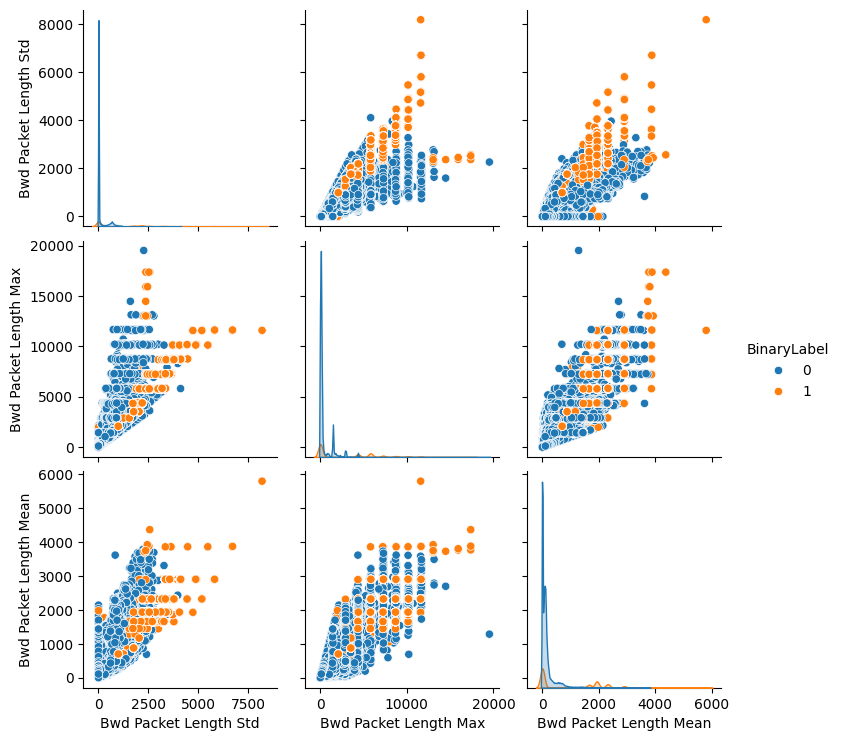

In [34]:
# Pairplot (강력한 조합 분석)

small_df = df[top_features[:3].tolist() + ["BinaryLabel"]]

sns.pairplot(small_df, hue="BinaryLabel", diag_kind="kde")
plt.show()

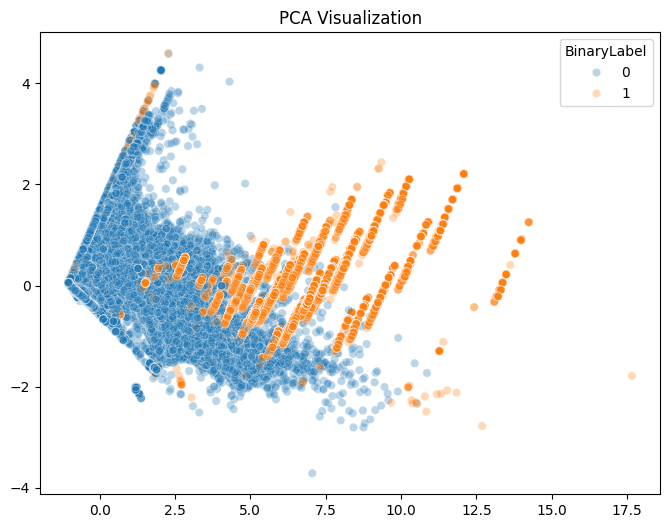

In [35]:
# PCA 2차 시각화


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_scaled = StandardScaler().fit_transform(df[top_features])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df["BinaryLabel"], alpha=0.3)
plt.title("PCA Visualization")
plt.show()

---

## 최종 정리
CICIDS2017 데이터는 실제 네트워크 환경에서 수집된 트래픽을 기반으로 다양한 공격 시나리오를 포함하고 있다.
통계적 Flow Feature를 통해 공격 패턴을 정량적으로 분석할 수 있도록 설계되었다. 
이는 단순한 로그 데이터가 아니라 네트워크 행위를 수치화한 고차원 보안 분석 데이터라는 점에서 의미를 가질 것 같다.

---

## 🔍 향후 분석 목표

### 1. 공격 탐지 모델 구축 (Binary Classification)
EDA를 통해 정상(BENIGN) 트래픽과 공격 트래픽 간에 일부 Feature에서 뚜렷한 차이가 존재함을 확인하였다.  
추후에는 `BENIGN(0)` vs `ATTACK(1)` 이진 라벨을 기반으로 분류 모델을 구축하고
네트워크 Flow 통계 Feature만으로 공격 트래픽을 얼마나 효과적으로 탐지할 수 있는지 평가할 예정이당

### 2. 클래스 불균형 문제 고려 및 보안 관점 평가
CICIDS2017 데이터는 정상 트래픽이 다수를 차지하는 불균형 구조를 가진다.  
따라서 단순 Accuracy 중심 평가가 아닌 보안 환경에서 중요한 `Recall(탐지 누락 최소화)`과 `Precision(오탐 최소화)` 및 `F1-score`를 중심으로 성능을 평가하고 False Negative(공격 미탐) 위험을 최소화하는 방향으로 분석을 진행할 예정이다...

### 3. 이상 탐지(Anomaly Detection) 접근 실험
실제 운영 환경에서는 모든 공격 유형을 충분히 학습하기 어렵다는 점을 고려하여 정상 트래픽만을 학습한 뒤 이상 행위를 탐지하는 비지도 학습 기반 접근도 실험할 예정이다.  
Isolation Forest 등의 기법을 적용하여 정상 트래픽 분포에서 벗어난 Flow를 공격으로 탐지할 수 있는지 검증한다.

### 4. 공격 유형별 패턴 비교 및 Multi-class 분석 확장
데이터셋에는 DDoS, PortScan, Web Attack 등 다양한 공격 유형이 포함되어 있다.  
향후에는 공격 유형별 주요 Feature 차이를 비교하고 필요 시 Multi-class 분류를 통해 “어떤 공격인지”까지 구분 가능한지 확장 분석을 수행할 예정이다.

### 최종 목표 (요약)
본 분석의 최종 목표는 네트워크 Flow 기반 통계 Feature를 활용해 정상과 공격 트래픽을 효과적으로 구분하고 실제 IDS 환경을 가정했을 때 탐지 성능(특히 미탐 최소화)을 검증하는 것이다...